#  Détection du Glaucome – Projet RIM-ONE_DL - Modèle ResNet18 + DCGAN  + CLAHE + Augmentation
   Sirem Kaci, Aissa Cheroufa, Ahcene Hanafi, Nassim Khemich,
                     Yanis Hanouti, Lounes Saada

Objectif :
- Compréhension des données
- Préparation et transformation des données
- Modélisation.

**Approches utilisées :**
- Albumentations pour appliquer des augmentations agressives afin de compenser le désiquilibre
- Augmentations modérées adaptées aux images médicales
- Utilisation d'un modéle préentrainer.
- Suivi de l’entraînement via historique de loss et métriques F1/AUC
- Utilisation de  Weighted Sampling
- Évaluation sur le test set original + un **nouveau dataset indépendant (ACRIMA)**

---
**Objectif final :** Obtenir un modèle robuste et généralisable pour la détection précoce du glaucome.


## 1. Imports et Configuration Globale

Dans cette section, nous chargeons toutes les bibliothèques nécessaires et définissons les hyperparamètres principaux du projet.

In [ ]:
# =============================================================================
# 1. IMPORTS & CONFIGURATION GLOBALE
# =============================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch import amp
from torch.cuda.amp import autocast, GradScaler
from torchvision import models
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
from google.colab import drive

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
print("PyTorch version:", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM totale :", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
else:
    print(" ATTENTION : exécution sur CPU → très lent et risque de crash !!!")
    print("Active le GPU dans Runtime → Change runtime type → T4 GPU")

# Force AMP uniquement si GPU
USE_AMP = torch.cuda.is_available()

PyTorch version: 2.10.0+cu128
CUDA disponible : True
GPU : Tesla T4
VRAM totale : 15.637086208 GB


In [ ]:
# Configuration globale
IMG_SIZE       = 224
BATCH_SIZE     = 32          # 16–48 selon VRAM (T4 → 32 ok, A100 → 64+)
NUM_EPOCHS     = 300
LEARNING_RATE  = 1e-4        #3e-4 pour l'autre modele conv
WEIGHT_DECAY   = 1e-5
LABEL_SMOOTHING = 0.1
PATIENCE       = 25          # Pour early stopping manuel
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")

SAVE_DIR       = Path("/content/drive/MyDrive/Fusion")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = SAVE_DIR / "best_glaucoma_convnext.pth"

Device utilisé : cuda


## 2. Transformations et Prétraitement (Version agressive)

Nous utilisons **Albumentations** pour appliquer des augmentations agressives afin de compenser le désiquilibre ainsi que la variabilité adaptés aux images de fond d'œil.  
L'objectif est d'améliorer la robustesse du modèle sans déformer les caractéristiques médicales importantes (disque optique, excavation, etc.).


In [ ]:
# =============================================================================
# 2. TRANSFORMATIONS (Albumentations) - Avec CLAHE en augmentation
# =============================================================================

class AlbumentationsTransform:
    """Wrapper pour utiliser Albumentations avec torchvision datasets"""
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def __call__(self, img):
        img = np.array(img)
        result = self.pipeline(image=img)
        return result["image"]


# Pipeline Entraînement (avec CLAHE aléatoire)
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # CLAHE en augmentation (recommandé)
    A.CLAHE(clip_limit=(1.0, 4.0), tile_grid_size=(8, 8), p=0.65),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.Rotate(limit=40, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=20, val_shift_limit=20, p=0.4),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.25),
    A.CoarseDropout(max_holes=10, max_height=32, max_width=32, fill_value=0, p=0.35),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Pipeline Validation / Test (CLAHE léger pour cohérence)
val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),   # léger sur val/test
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_transform = AlbumentationsTransform(train_aug)
val_transform   = AlbumentationsTransform(val_aug)

print("CLAHE ajouté comme augmentation (p=0.65 sur train, p=0.5 sur val/test)")

CLAHE ajouté comme augmentation (p=0.65 sur train, p=0.5 sur val/test)


## 3. Datasets et DataLoaders

Nous créons les DataLoaders avec un **WeightedRandomSampler** pour garantir un échantillonnage équilibré pendant l'entraînement, même après l'équilibrage manuel.

In [ ]:
# =============================================================================
# 3. DATASETS & DATALOADERS
# =============================================================================



DATA_ROOT = Path("/content/drive/MyDrive/Fusion")

# ─── Train complet ─────────────────────────
full_train = ImageFolder(DATA_ROOT / "train", transform=train_transform)

# ─── Split Train / Val ─────────────────────
train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size

train_ds, val_ds = random_split(full_train, [train_size, val_size])

# ─── Test ──────────────────────────────────
test_ds = ImageFolder(DATA_ROOT / "test", transform=val_transform)

# ─── Infos ─────────────────────────────────
print(f"Classes détectées : {full_train.classes}")
print(f"Train : {len(train_ds)} images")
print(f"Val   : {len(val_ds)} images")
print(f"Test  : {len(test_ds)} images")

# ─── Imbalance (global) ────────────────────
labels = [s[1] for s in full_train.samples]
class_counts = np.bincount(labels)
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Ratio majoritaire/minoritaire : {imbalance_ratio:.2f}:1")

# ─── Weighted Sampler (SUR TRAIN UNIQUEMENT) ─────────────────
from torch.utils.data import WeightedRandomSampler

# indices du train split
train_indices = train_ds.indices

# labels correspondant au TRAIN uniquement
train_targets = [full_train.samples[i][1] for i in train_indices]

# comptage par classe
class_sample_count = np.bincount(train_targets)

# poids inverses
class_weights = 1. / class_sample_count

# poids pour chaque image
sample_weights = [class_weights[t] for t in train_targets]

# sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ─── DataLoaders ───────────────────────────
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,          #  utilisé ici
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Classes détectées : ['0', '1']
Train : 6671 images
Val   : 1668 images
Test  : 916 images
Ratio majoritaire/minoritaire : 1.02:1


# 4. Définition des modèles

Nous définissons les architectures de modèles pour la classification du glaucome à partir d'images fundus.

---

## Modèles disponibles

1. **GlaucomaConvNeXt**  
   - Basé sur **ConvNeXt-Tiny**, léger et efficace pour des datasets de petite taille.  
   - Le `Flatten` avant le `LayerNorm` corrige la normalisation pour la couche finale.  

2. **GlaucomaEfficientNetV2**  
   - Basé sur **EfficientNetV2-S**, bon compromis précision / vitesse.  
   - Utilisé pour des images de résolution moyenne, plus performant mais un peu plus lourd.

---

## Choix du modèle

On sélectionne ici le modèle à utiliser pour l'entraînement et l'évaluation.  
Le nombre de paramètres entraînables est affiché pour évaluer la complexité du modèle.

In [ ]:
# =============================================================================
# 4. DÉFINITION DES MODÈLES
# =============================================================================

class GlaucomaConvNeXt(nn.Module):
    """ConvNeXt-Tiny avec correction LayerNorm"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.base = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

        #  Classifier
        in_features = self.base.classifier[2].in_features
        self.base.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.base(x)


class GlaucomaEfficientNetV2(nn.Module):
    """EfficientNetV2-S"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.base = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.base(x)


# ====================== CHOIX ET CRÉATION DU MODÈLE ======================
MODEL_CLASS = GlaucomaConvNeXt
model = MODEL_CLASS(num_classes=2).to(DEVICE)

print(f"Modèle sélectionné : {MODEL_CLASS.__name__}")
print(f"Paramètres totaux    : {sum(p.numel() for p in model.parameters()):,}")
print(f"Paramètres entraînables (avant unfreezing) : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 161MB/s]


Modèle sélectionné : GlaucomaConvNeXt
Paramètres totaux    : 27,821,666
Paramètres entraînables (avant unfreezing) : 27,821,666


In [ ]:
# =============================================================================
#  FULL FINE-TUNING
# =============================================================================

for param in model.base.parameters():
    param.requires_grad = True   #  UNFREEZE TOTAL

print(" FULL FINE-TUNING ACTIVÉ (tout le backbone est entraînable)")

# Optimizer adapté (plus petit LR)
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,   #  LR plus petit pour fine-tuning complet
    weight_decay=WEIGHT_DECAY
)

 FULL FINE-TUNING ACTIVÉ (tout le backbone est entraînable)


##  Modèle CNN Classique (Alternative à ConvNeXt)

Dans cette section, nous remplaçons le modèle **ConvNeXt** par un **CNN classique** afin de :

-  Améliorer la stabilité de l’entraînement  
-  Réduire le risque de prédiction d’une seule classe)
-  Mieux s’adapter à un dataset de taille limitée  
-  Faciliter le debug et l’interprétation  

---

###  Architecture du modèle

Le modèle est composé de :

- 4 blocs convolutionnels :
  - `Conv2D et BatchNorm et ReLU et MaxPooling`
- Un **Global Average Pooling** pour éviter les erreurs de dimension
- Un **Dropout (0.5)** pour limiter l’overfitting
- Une couche fully connected finale (`Linear`) avec **2 classes**



In [ ]:
# ─────────────────────────────────────────────
# CNN CLASSIQUE STABLE (remplace ConvNeXt)
# ─────────────────────────────────────────────

class GlaucomaSimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc 4 (ajout pour stabilité)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Global pooling pour éviter les erreurs de taille
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ─── Remplacement du modèle ───────────────────
MODEL_CLASS = GlaucomaSimpleCNN
model = MODEL_CLASS(num_classes=2).to(DEVICE)

print(f"Modèle sélectionné : {MODEL_CLASS.__name__}")
print(f"Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Modèle sélectionné : GlaucomaSimpleCNN
Paramètres entraînables : 389,890


# 5. Loss – Optimizer – Scheduler – Scaler AMP

Dans cette cellule, nous définissons les éléments essentiels pour l'entraînement du modèle : la fonction de perte, l'optimiseur, le scheduler et le scaler pour l'AMP.

---

##  Fonction de perte (Loss)

- On utilise **CrossEntropyLoss** pour la classification binaire.  
- `label_smoothing=0.1` aide à régulariser le modèle et réduire le surapprentissage.  
- `class_weights` est calculé pour compenser le déséquilibre entre les classes (normal / glaucome).

In [ ]:
# =============================================================================
# 6. LOSS - OPTIMIZER - SCHEDULER - SCALER
# =============================================================================


# ===================== CLASS WEIGHTS =====================
labels = [s[1] for s in full_train.samples]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# ===================== LOSS =====================
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING,
    weight=class_weights
)

# ===================== OPTIMIZER (IMPORTANT FIX) =====================
optimizer = optim.AdamW(
    model.parameters(),   #  IMPORTANT: PAS de filter()
    lr=1e-5,
    weight_decay=WEIGHT_DECAY
)

# ===================== SCHEDULER =====================
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,   #  plus réactif (important pour fine-tuning)
    min_lr=1e-7
)

# ===================== AMP =====================
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

print(" Loss, Optimizer et Scheduler initialisés avec succès")
print(f"   → Loss : CrossEntropyLoss (label smoothing + weights)")
print(f"   → LR initial : {1e-5}")
print(f"   → Device : {DEVICE}")

 Loss, Optimizer et Scheduler initialisés avec succès
   → Loss : CrossEntropyLoss (label smoothing + weights)
   → LR initial : 1e-05
   → Device : cuda


# 6. Fonction d'évaluation

Cette fonction calcule les métriques détaillées sur un loader donné :

- `loss` moyen
- `accuracy`
- `precision`, `recall`, `f1-score`
- `AUC`

Elle applique un **seuil (`threshold`)** pour convertir les probabilités en prédictions binaires et retourne un dictionnaire des métriques.  
La matrice de confusion est également affichée pour suivi rapide.



In [ ]:
# =============================================================================
# 6. FONCTION D'ÉVALUATION (métriques détaillées)
# =============================================================================


@torch.no_grad()
def evaluate_tta(loader, model, criterion, device, threshold=0.3):
    model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    for images, labels in tqdm(loader, desc="TTA Evaluation", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # === ORIGINAL ===
        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            outputs1 = model(images)

        # === HORIZONTAL FLIP ===
        flipped_images = torch.flip(images, dims=[3])  # flip horizontal
        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            outputs2 = model(flipped_images)

        # === PROBABILITÉS ===
        probs1 = torch.softmax(outputs1, dim=1)[:, 1]
        probs2 = torch.softmax(outputs2, dim=1)[:, 1]

        #  MOYENNE
        final_probs = (probs1 + probs2) / 2

        # LOSS (optionnel)
        loss = criterion(outputs1.float(), labels)
        total_loss += loss.item() * images.size(0)

        all_probs.extend(final_probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # === THRESHOLD ===
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs > threshold).astype(int)

    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score, confusion_matrix

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, preds, average='binary', zero_division=0
    )

    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0

    print("\nConfusion Matrix (TTA):")
    print(confusion_matrix(all_labels, preds))

    return {
        "loss": total_loss / len(loader.dataset),
        "acc": acc * 100,
        "precision": precision * 100,
        "recall": recall * 100,
        "f1": f1 * 100,
        "auc": auc * 100
    }

# 7. Boucle d'entraînement principale

Cette boucle :

- entraîne le modèle pendant `NUM_EPOCHS` époques
- utilise **AMP** pour accélérer le calcul sur GPU
- suit les métriques de validation (`f1`, `loss`, `auc`)
- applique **early stopping** si le F1 ne s'améliore pas depuis `PATIENCE` époques
- sauvegarde le **meilleur modèle** (`BEST_MODEL_PATH`)
- met à jour `history` pour tracer ensuite les courbes d'apprentissage

In [ ]:
# =============================================================================
# 7. BOUCLE D'ENTRAÎNEMENT PRINCIPALE
# =============================================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": [],
    "val_recall": []
}

best_val_f1 = 0.0
best_epoch = 0
patience_counter = 0

print("\n" + "═" * 80)
print("DÉBUT ENTRAÎNEMENT - ConvNeXt-Tiny sur T4".center(80))
print("═" * 80 + "\n")

UNFREEZE_EPOCH = 30
has_unfrozen = False

for epoch in range(1, NUM_EPOCHS + 1):

    # ===== UNFREEZING COMPLET =====
    if epoch == UNFREEZE_EPOCH and not has_unfrozen:
        print("\n UNFREEZING COMPLET DU MODÈLE \n")

        for param in model.base.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(
            model.parameters(),
            lr=1e-5,
            weight_decay=WEIGHT_DECAY
        )

        has_unfrozen = True

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch:2d}/{NUM_EPOCHS} [Train]", leave=True)

    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        # ===== AMP SAFE =====
        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # ===== TRAIN METRICS =====
    train_loss /= train_total
    train_acc = 100. * train_correct / train_total

    # ===== VALIDATION (UTILISE TA FONCTION EXISTANTE) =====
    val_metrics = evaluate_tta(val_loader, model, criterion, DEVICE, threshold=0.3)

    # ===== HISTORY =====
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_recall"].append(val_metrics["recall"])

    # ===== DISPLAY =====
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:5.2f}% | "
          f"Val Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:5.2f}% | "
          f"F1: {val_metrics['f1']:5.2f}% | Recall: {val_metrics['recall']:5.2f}% | "
          f"AUC: {val_metrics['auc']:5.2f}%")

    # ===== SCHEDULER =====
    scheduler.step(val_metrics['f1'])

    # ===== EARLY STOPPING =====
    if val_metrics['f1'] > best_val_f1 + 0.01:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f" → Nouveau meilleur F1 ! Sauvegardé (F1 = {best_val_f1:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping à l'époque {epoch} (pas d'amélioration F1 depuis {PATIENCE} epochs)")
            break

    # ===== CLEAN GPU =====
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "═" * 80)
print(f"ENTRAÎNEMENT TERMINÉ - Meilleur F1 val : {best_val_f1:.2f}% (époque {best_epoch})")
print(f"Modèle sauvegardé → {BEST_MODEL_PATH}")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
                   DÉBUT ENTRAÎNEMENT - ConvNeXt-Tiny sur T4                    
════════════════════════════════════════════════════════════════════════════════



Epoch  1/300 [Train]:   0%|          | 0/208 [00:00<?, ?it/s]

TTA Evaluation:   0%|          | 0/53 [00:00<?, ?it/s]


Confusion Matrix (TTA):
[[385 460]
 [ 51 772]]
Epoch  1/300 | Train Loss: 0.6719 | Acc: 61.91% | Val Loss: 0.5427 | Acc: 69.36% | F1: 75.13% | Recall: 93.80% | AUC: 83.66%
 → Nouveau meilleur F1 ! Sauvegardé (F1 = 75.13%)


Epoch  2/300 [Train]:   0%|          | 0/208 [00:00<?, ?it/s]

...

Epoch 58/300 [Train]:   0%|          | 0/208 [00:00<?, ?it/s]

TTA Evaluation:   0%|          | 0/53 [00:00<?, ?it/s]


Confusion Matrix (TTA):
[[696 149]
 [ 38 785]]
Epoch 58/300 | Train Loss: 0.3208 | Acc: 92.35% | Val Loss: 0.3843 | Acc: 88.79% | F1: 89.36% | Recall: 95.38% | AUC: 95.63%


Epoch 59/300 [Train]:   0%|          | 0/208 [00:00<?, ?it/s]

TTA Evaluation:   0%|          | 0/53 [00:00<?, ?it/s]

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9]:
    metrics = evaluate(test_loader, model, criterion, DEVICE, threshold=t)
    print(f"Threshold {t} → F1: {metrics['f1']:.2f}, Recall: {metrics['recall']:.2f}")

Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[446  33]
 [ 15 422]]
Threshold 0.2 → F1: 94.62, Recall: 96.57


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[447  32]
 [ 18 419]]
Threshold 0.3 → F1: 94.37, Recall: 95.88


Validation:   0%|          | 0/29 [00:00<?, ?it/s]

...


Confusion Matrix:
[[457  22]
 [ 34 403]]
Threshold 0.8 → F1: 93.50, Recall: 92.22


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[457  22]
 [ 40 397]]
Threshold 0.85 → F1: 92.76, Recall: 90.85


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[459  20]
 [ 47 390]]
Threshold 0.9 → F1: 92.09, Recall: 89.24


# 8. Évaluation finale sur le Test Set

Cette cellule réalise l'évaluation finale du modèle entraîné sur le jeu de test.

---

##  Chargement du meilleur modèle

- On charge les poids sauvegardés lors du meilleur F1 sur la validation.  
- Le modèle est mis en mode évaluation (`model.eval()`).




════════════════════════════════════════════════════════════
             ÉVALUATION FINALE SUR LE TEST SET              
════════════════════════════════════════════════════════════



Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[447  32]
 [ 48 389]]
Test Loss     : 0.3386
Test Accuracy : 91.27 %
Test Precision: 92.40 %
Test Recall   : 89.02 %
Test F1       : 90.68 %
Test AUC      : 97.00 %


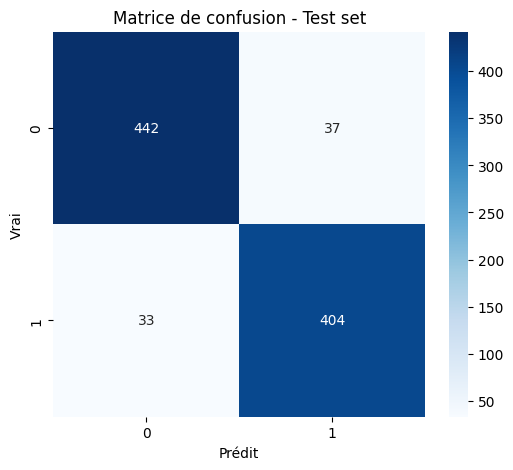

In [ ]:
# =============================================================================
# 8. ÉVALUATION FINALE SUR TEST
# =============================================================================


model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

print("\n" + "═" * 60)
print("ÉVALUATION FINALE AVEC TTA".center(60))
print("═" * 60 + "\n")

#  Test avec TTA
test_metrics = evaluate_tta(test_loader, model, criterion, DEVICE, threshold=0.3)

print(f"Test Loss     : {test_metrics['loss']:.4f}")
print(f"Test Accuracy : {test_metrics['acc']:.2f} %")
print(f"Test Precision: {test_metrics['precision']:.2f} %")
print(f"Test Recall   : {test_metrics['recall']:.2f} %")
print(f"Test F1       : {test_metrics['f1']:.2f} %")
print(f"Test AUC      : {test_metrics['auc']:.2f} %")

## 9. Visualisations et Analyse de l'Entraînement

Nous affichons :
- L'évolution de la loss et des métriques
- La matrice de confusion sur le test set
- La distribution des probabilités prédites

Ces graphiques permettent de détecter rapidement un éventuel **surapprentissage**.

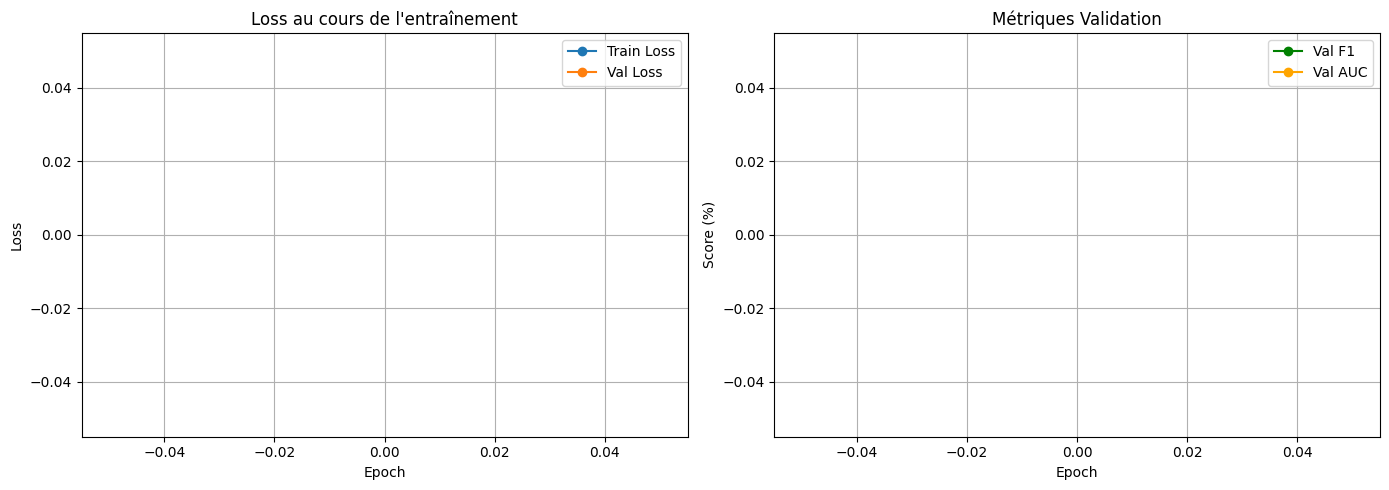

Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Confusion Matrix:
[[450  29]
 [ 23 414]]


KeyError: 'cm'

In [ ]:

# Chargement du meilleur modèle
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

# Courbes d'apprentissage
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.plot(history["val_loss"], label="Val Loss", marker='o')
plt.title("Loss au cours de l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history["val_f1"], label="Val F1", marker='o', color='green')
plt.plot(history["val_auc"], label="Val AUC", marker='o', color='orange')
plt.title("Métriques Validation")
plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Matrice de confusion finale (test set)
test_metrics = evaluate(test_loader, model, criterion, DEVICE)
sns.heatmap(test_metrics["cm"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Glaucoma"], yticklabels=["Normal", "Glaucoma"])
plt.title("Matrice de Confusion - Test Set")
plt.ylabel("Vraie classe")
plt.xlabel("Prédiction")
plt.show()

# Histogramme des probabilités
plt.figure(figsize=(8, 5))
sns.histplot(test_metrics["probs"], bins=50, kde=True)
plt.axvline(THRESHOLD, color='red', linestyle='--', label=f"Seuil {THRESHOLD}")
plt.title("Distribution des probabilités de Glaucome (Test)")
plt.xlabel("Probabilité prédite")
plt.legend()
plt.show()

## 10. Test sur un Nouveau Dataset Indépendant (ACRIMA)

Pour évaluer la **vraie capacité de généralisation** du modèle, nous le testons sur un dataset complètement différent : **ACRIMA**.

Ce test est crucial car il permet de vérifier si le modèle performe bien sur des images provenant d'une autre source (différents appareils, populations, etc.).

In [ ]:
# =============================================================================
# 10. TEST SUR UN NOUVEAU DATASET (ACRIMA) + Visualisations
# =============================================================================

# ─── Chemin du nouveau dataset ─────────────────────────────────────
NEW_TEST_DIR = "/content/drive/MyDrive/ORIGA/ORIGA/Testing"

# On utilise la même transformation que pour le test original
new_test_transform = val_transform

# Chargement du nouveau dataset
new_test_ds = ImageFolder(NEW_TEST_DIR, transform=new_test_transform)

new_test_loader = DataLoader(
    new_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,                    # Important sur Colab pour éviter les bugs
    pin_memory=torch.cuda.is_available()
)

print(f"Nouveau dataset chargé : {len(new_test_ds)} images")
print(f"Classes détectées : {new_test_ds.classes}")


# ─── Chargement du meilleur modèle  ─────────────────────
print("\nChargement du meilleur modèle...")

# Charger le meilleur modèle pour le test
loaded_model = MODEL_CLASS(num_classes=2).to(DEVICE)
loaded_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
loaded_model.eval()

print(f"Modèle chargé : {MODEL_CLASS.__name__}")


# ─── Fonction d'évaluation sur nouveau dataset ─────────────────────────────
@torch.no_grad()
def test_on_new_dataset(loader, model, device, class_names=["Normal", "Glaucoma"], display=False):
    """
    Évalue un modèle sur un dataset et affiche métriques et graphiques
    display=False pour désactiver les visualisations
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Test sur ACRIMA"):
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()   # probabilité de Glaucoma
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    # Calcul des métriques
    acc = accuracy_score(all_labels, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    # ─── Affichage des résultats principaux ─────────────────────────
    print("\n" + "═"*65)
    print("RÉSULTATS FINAUX SUR LE NOUVEAU DATASET (ACRIMA)".center(65))
    print("═"*65)
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {precision*100:.2f}%")
    print(f"Recall    : {recall*100:.2f}%")
    print(f"F1-Score  : {f1*100:.2f}%")
    print(f"AUC       : {auc*100:.2f}%")
    print("═"*65)

    print("\nRapport de classification détaillé :")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    cm = confusion_matrix(all_labels, all_preds)

    # ─── Visualisations optionnelles ──────────────────────────────
    if display:
        # Matrice de confusion
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Matrice de Confusion - Dataset ACRIMA')
        plt.ylabel('Vraie Classe')
        plt.xlabel('Classe Prédite')
        plt.show()

        # Distribution des probabilités
        plt.figure(figsize=(8, 5))
        sns.histplot(all_probs, bins=50, kde=True, color='purple')
        plt.axvline(THRESHOLD, color='red', linestyle='--', label=f'Seuil = {THRESHOLD}')
        plt.title('Distribution des probabilités de Glaucome (ACRIMA)')
        plt.xlabel('Probabilité prédite')
        plt.ylabel('Nombre d\'images')
        plt.legend()
        plt.show()

    return {
        "accuracy": acc,
        "f1": f1*100,
        "recall": recall*100,
        "auc": auc*100,
        "cm": cm
    }


# ─── Lancement du test sur le nouveau dataset ───────────────────────────────

new_test_results = test_on_new_dataset(
    new_test_loader,
    loaded_model,
    DEVICE,
    class_names=new_test_ds.classes,
    display=False
)

Nouveau dataset chargé : 130 images
Classes détectées : ['glaucoma', 'normal']

Chargement du meilleur modèle...
Modèle chargé : GlaucomaConvNeXt


Test sur ACRIMA:   0%|          | 0/5 [00:00<?, ?it/s]


═════════════════════════════════════════════════════════════════
         RÉSULTATS FINAUX SUR LE NOUVEAU DATASET (ACRIMA)        
═════════════════════════════════════════════════════════════════
Accuracy  : 25.38%
Precision : 48.65%
Recall    : 18.75%
F1-Score  : 27.07%
AUC       : 21.94%
═════════════════════════════════════════════════════════════════

Rapport de classification détaillé :
              precision    recall  f1-score   support

    glaucoma     0.1613    0.4412    0.2362        34
      normal     0.4865    0.1875    0.2707        96

    accuracy                         0.2538       130
   macro avg     0.3239    0.3143    0.2534       130
weighted avg     0.4014    0.2538    0.2617       130



In [ ]:
!ls "/content/drive/MyDrive"

 ACRIMA		   'Copie de Finale.ipynb'      Fusion
'Colab Notebooks'  'Copie de Untitled0.ipynb'   ORIGA


In [ ]:
!ls "/content/drive/MyDrive/ORIGA/ORIGA"

Testing  Training


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
